## Basic Setup

In [1]:
from dotenv import load_dotenv
load_dotenv()

from langchain_nvidia_ai_endpoints import ChatNVIDIA
import os

llm = ChatNVIDIA(model=os.environ.get('LLM_MODEL'))
llm

ChatNVIDIA(base_url='https://integrate.api.nvidia.com/v1', model='meta/llama-3.1-405b-instruct', default_headers={})

## Graph Creation

### Pydantic Schema

In [2]:
from pydantic import BaseModel, Field, field_validator

class LinkedInPostState(BaseModel):
    topic: str = Field(..., description="The main topic of the LinkedIn post")
    content: str = Field(default="", description="The main content of the LinkedIn post")
    curated_content: str = Field(default="", description="Curated content to include in the LinkedIn post")
    # Defaulting to an empty list is safer for iteration
    hashtags: list[str] = Field(default_factory=list, description="List of hashtags to include in the LinkedIn post")

    @field_validator("hashtags")
    def ensure_hash_prefix(cls, v):
        """Ensures every hashtag starts with a '#' symbol."""
        return [tag if tag.startswith("#") else f"#{tag}" for tag in v]


### Content Creator Node

In [14]:
def content_creator_node(state: LinkedInPostState):
    prompt = f"""
    You are a LinkedIn content creator. Your task is to create a LinkedIn post based on the following information:

    Topic: {state.topic}

    You need to generate a Content for the LinkedIn post.
    No explainaition is required, just give pure content.
    Dont include hashtags.
    """

    response = llm.invoke(prompt)

    generated_content = response.content

    state.content = str(generated_content)

    return state

### Content Curator Node

In [15]:
def content_curator_node(state: LinkedInPostState):
    prompt = f"""
    Yor are a professional LinkedIn content curator. Your task is to curate the below content to look more professional and knowlagable.

    Content: {state.content}

    No explainaition is required, just give pure content.
    Dont include hashtags.
    """

    response = llm.invoke(prompt)

    generated_content = response.content

    state.curated_content = str(generated_content)

    return state

### HashTag generator

In [9]:
def hashtag_generator_node(state: LinkedInPostState):
    prompt = f"""
    Yor are a professional LinkedIn hashtag generator. Your task is to generate hashtags for the below content which helps the post go viral.

    Content: {state.curated_content}

    Make sure every hashtag is prefexed by # and seperated by comma.
    No explainations are required, just give comma seperated hashtags.
    """

    response = llm.invoke(prompt)

    hashtags = [tag.strip() for tag in str(response.content).split(",") if tag.strip()]

    state.hashtags = hashtags

    return state

### Graph Creation

In [6]:
from langgraph.graph import StateGraph, START, END

def create_linkedin_graph():
    graph = StateGraph(state_schema=LinkedInPostState)

    graph.add_node("content_creator_node", content_creator_node)
    graph.add_node("content_curator_node", content_curator_node)
    graph.add_node("hashtag_generator_node", hashtag_generator_node)

    graph.add_edge(START, "content_creator_node")
    graph.add_edge("content_creator_node", "content_curator_node")
    graph.add_edge("content_curator_node", "hashtag_generator_node")
    graph.add_edge("hashtag_generator_node", END)

    return graph.compile()

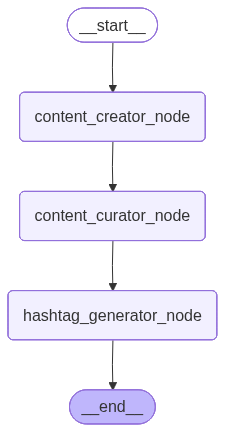

In [7]:
from IPython.display import Image

Image(create_linkedin_graph().get_graph().draw_mermaid_png())

### Testing

In [16]:
create_linkedin_graph().invoke(input=LinkedInPostState(topic="LangGraph in a realworld"))

{'topic': 'LangGraph in a realworld',
 'content': '"Unlocking the Power of LangGraph in the Real World\n\nAs we continue to push the boundaries of innovation, one technology is revolutionizing the way we approach natural language processing: LangGraph. But what does this mean for us in the real world?\n\nFrom enhancing customer service chatbots to improving language translation software, LangGraph is transforming the way we interact with technology. With its ability to analyze and understand complex language structures, LangGraph is enabling businesses to provide more personalized and effective customer experiences.\n\nIn the healthcare industry, LangGraph is being used to develop AI-powered diagnostic tools that can analyze medical records and provide more accurate diagnoses. In finance, it\'s being used to detect and prevent financial crimes by analyzing vast amounts of transaction data.\n\nBut LangGraph\'s impact doesn\'t stop there. It\'s also being used in education to develop mor